
### О ЛР:

- scikit-learn & decision trees
- Coding decision tree & Categorical features


----

#### Самостоятельная оценка результатов

Для удобства проверки, исходя из набора решенных задач, посчитайте свою максимальную оценку.

**Оценка**:

***DeadLine - 21.05.2024 23:59***

### Формат сдачи
Задания сдаются через lms. Вы прикрепляете **ССЫЛКУ НА ПУБЛИЧНЫЙ РЕПОЗИТОРИЙ**, где выполнено ваше задание. Иначе задание не проверяется.




### Оценивание и штрафы


Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 5 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты не могут получить за него больше 0 баллов.

Неэффективная реализация кода может негативно отразиться на оценке.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

sns.set(style="whitegrid")

import warnings

warnings.filterwarnings("ignore")

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=0.8,
        random_state=3,
        n_redundant=0.0,
    ),
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

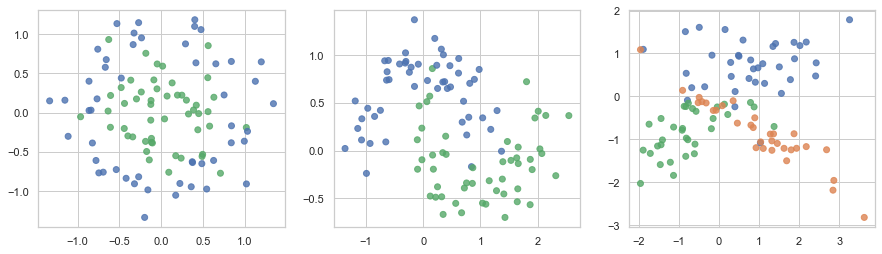

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=0.8)

__Задание 1. [0.5 балла]__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [7]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
    )
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=cmap,
        alpha=0.7,
        edgecolors=np.array(palette)[y],
        linewidths=2,
    )

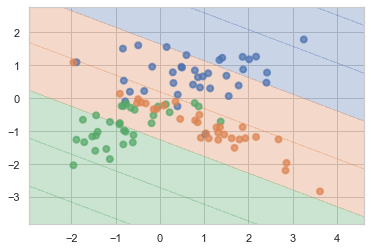

In [8]:
# Пример:
from sklearn.linear_model import LinearRegression

X, y = datasets[2]
lr = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

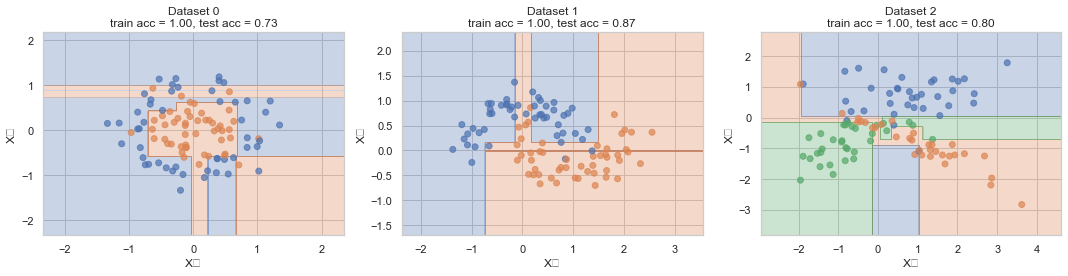

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# небольшая модификация чтобы лучше выглядело
def plot_surface(clf, X, y, ax):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    ax.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=cmap,
        alpha=0.7,
        edgecolors=np.array(palette)[y],
        linewidths=1
    )


n = len(datasets)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

for idx, (X, y) in enumerate(datasets):
    ax = axes[idx] if n > 1 else axes

    # 1) Разбиение
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 2) Обучение дерева
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)

    # 3) Метрики
    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test,  y_test)

    # 4) Строим разделяющие поверхности
    plot_surface(clf, X, y, ax)
    ax.set_title(
        f"Dataset {idx}\n"
        f"train acc = {train_acc:.2f}, test acc = {test_acc:.2f}"
    )
    ax.set_xlabel("X₁")
    ax.set_ylabel("X₂")

plt.tight_layout()
plt.show()


## Вывод

- На всех трёх наборах дерево достигает 100 % точности на обучении, то есть полностью «запоминает» выборку.  
- Тестовая точность заметно ниже:  
  - **Dataset 0**: 0.73  
  - **Dataset 1**: 0.87  
  - **Dataset 2**: 0.80  
- Самое сильное переобучение наблюдается на Dataset 0 (наибольший разрыв между train и test).  
- Чтобы снизить переобучение, стоит ввести регуляризацию:  
  - ограничить глубину дерева (`max_depth`),  
  - повысить минимальное число объектов в листе (`min_samples_leaf`),  
  - добавить другие ограничения (например, `min_samples_split`, `max_leaf_nodes`).  


__Задание 2. [0.75 балла]__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

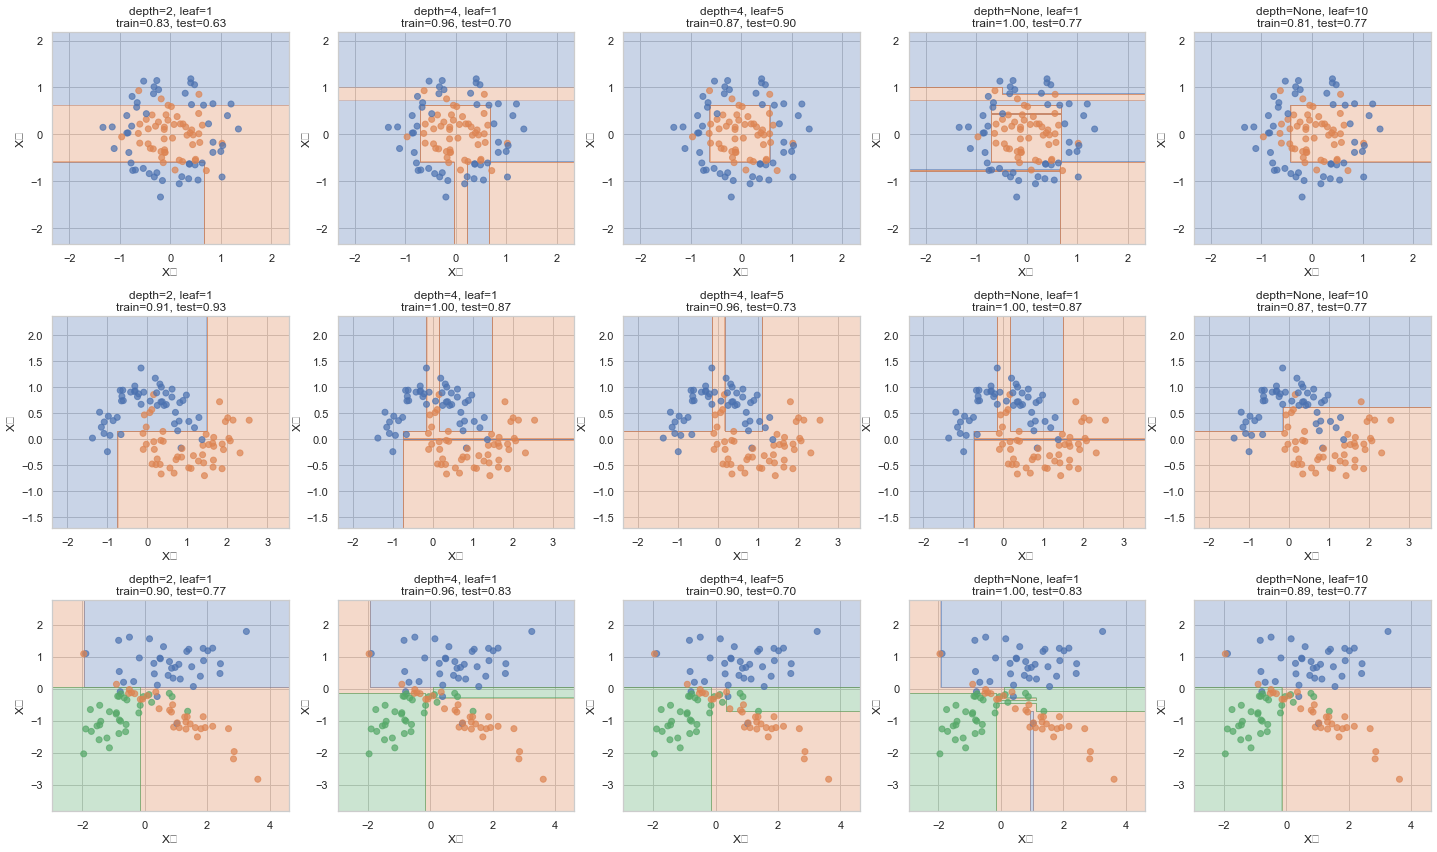

In [11]:
# разбиваем один раз для всех экспериментов
splits = [train_test_split(X, y, test_size=0.3, random_state=42) 
          for X,y in datasets]

# сет гиперпараметров
param_grid = [
    {'max_depth': 2, 'min_samples_leaf': 1},
    {'max_depth': 4, 'min_samples_leaf': 1},
    {'max_depth': 4, 'min_samples_leaf': 5},
    {'max_depth': None, 'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_leaf': 10},
]

fig, axes = plt.subplots(
    len(datasets), len(param_grid),
    figsize=(4*len(param_grid), 4*len(datasets)),
    squeeze=False
)

for i, ((X_train, X_test, y_train, y_test), (X, y)) in enumerate(zip(splits, datasets)):
    for j, params in enumerate(param_grid):
        clf = DecisionTreeClassifier(**params).fit(X_train, y_train)
        tr = clf.score(X_train, y_train)
        te = clf.score(X_test, y_test)
        ax = axes[i, j]
        plot_surface(clf, X, y, ax)
        ax.set_title(
            f"depth={params['max_depth']}, leaf={params['min_samples_leaf']}\n"
            f"train={tr:.2f}, test={te:.2f}"
        )
        ax.set_xlabel("X₁")
        ax.set_ylabel("X₂")

plt.tight_layout()
plt.show()


## Вывод по результатам регуляризации

- **depth=2, leaf=1**  
  – Недообучение: и train, и test низкие на всех трёх датасетах.  
- **depth=4, leaf=1**  
  – Сильная гибкость: train поднимается почти до 1.0, но test падает из-за переобучения.  
- **depth=4, leaf=5**  
  – Лучший компромисс на Dataset 0 (test≈0.90) и заметное сглаживание границы: разрыв между train/test значительно сокращается.  
- **depth=None, leaf=1**  
  – Максимальное переобучение (train=1.0), test хуже, чем при ограничениях depth или leaf.  
- **depth=None, leaf=10**  
  – Слишком жёсткая регуляризация через большой `min_samples_leaf`: недообучение (train↓), test ≈0.77 стабильно.

- **Переход от одного датасета к другому**  
  - **Dataset 0** (шумный «плотный» кластер): требует жёсткой регуляризации (depth=4, leaf=5).  
  - **Dataset 1** (чёткие разделённые кластеры): достаточно неглубокого дерева (depth=2) для лучшей обобщающей способности (test≈0.93).  
  - **Dataset 2** (простая линейно-/условно-разделимая структура): глубокие деревья с малыми листьями (depth=4–None, leaf=1) дают максимальную тестовую точность (≈0.83).

**Итог:** оптимальные значения `max_depth` и `min_samples_leaf` зависят от характера данных: шумным наборам нужны более строгие ограничения, а при простой геометрии можно позволить модели больше гибкости.


# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. [0.75 балл]__

Реализуйте функцию `find_best_split` из модуля `tree_code.py`

__Задание 4. [0.25 балла]__

`students.csv` - это преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). Первые пять столбцов содержат признаки каждого объекта, а последний столбец — целевую переменную (класс: 0 или 1). Нужно построить график, который на одном изображении отобразит пять кривых "порог — значение критерия Джини" для всех пяти признаков. Кроме того, стоит отдельно визуализировать scatter-графики "значение признака — класс" для каждого из пяти признаков.

Это нужно и для выявления значимости признаков, и для пороговых значений. Да и глазу приятно

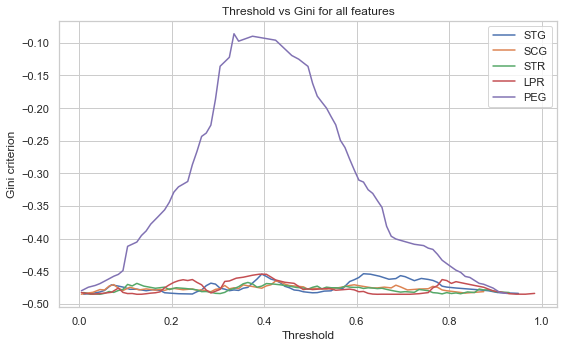

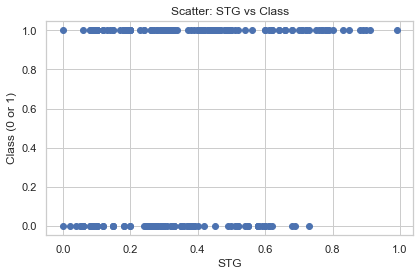

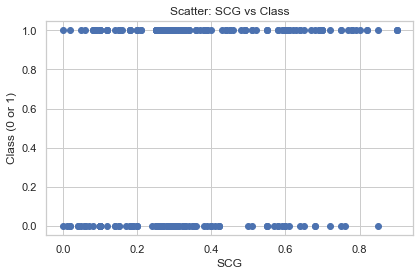

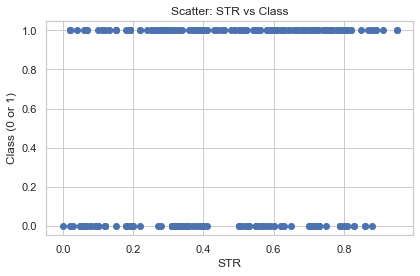

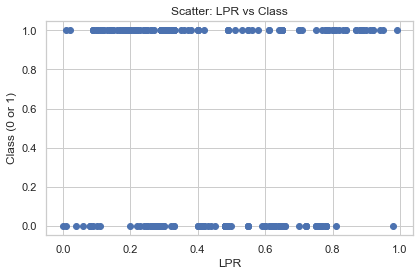

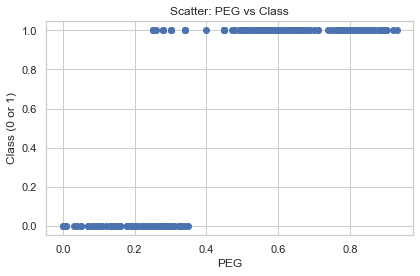

In [12]:
from tree_code import find_best_split

df = pd.read_csv('students.csv')  
features = df.columns[:-1]   # первые пять столбцов
y = df.iloc[:, -1].values    # последний столбец — класс

# --- 1) порог vs Gini для всех признаков ---
plt.figure(figsize=(8, 5))
for feat in features:
    th, gi, _, _ = find_best_split(df[feat].values, y)
    plt.plot(th, gi, label=feat)
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Gini criterion')
plt.title('Threshold vs Gini for all features')
plt.tight_layout()
plt.show()

# --- 2) scatter: значение признака vs класс ---
for feat in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feat], y)
    plt.xlabel(feat)
    plt.ylabel('Class (0 or 1)')
    plt.title(f'Scatter: {feat} vs Class')
    plt.tight_layout()
    plt.show()

__Задание 5. [0.25 балла]__

На основании кривых критерия Джини, по какому признаку стоит разделить выборку на два поддерева? Совпадает ли этот выбор с визуальной оценкой scatter-графиков? Как бы вы описали вид кривой для "хороших" признаков, по которым выборка делится почти идеально, и чем кривые таких признаков отличаются от кривых признаков, по которым разделение практически невозможно?


1. **Лучший признак для сплита**  
   - **PEG**.  
     - Его кривая Gini показывает самый высокий (в абсолютном значении) и чётко выраженный пик около порога ≈ 0.35.  
     - На scatter-графике по PEG действительно видно, что при этом пороге почти все классы 0 и 1 оказываются по разные стороны — выбор подтверждается визуально.

2. **Характеристики «хорошей» кривой Gini**  
   - **Острый высокий пик** в узкой области порогов: резкий рост качества разделения.  
   - **Локализованность**: после пика кривая быстро возвращается к фоновой линии.

3. **Характеристики «плохой» кривой Gini**  
   - **Плоскость или слабый шум**: значения Gini почти не меняются, без заметного экстремума.  
   - **Отсутствие выраженного порога**: ни один порог не даёт существенного выигрыша в разделении.

> **Вывод:**  
> По характеру пиков (высота и острота) на кривых Gini можно определить, какие признаки дают качественный сплит. Признаки с «острой» высокой кривой — хорошие кандидаты для первого разбиения, «плоские» кривые — неинформативны.  


__Задание 6. [0.75 балла].__

Разберитесь с уже написанным кодом в классе DecisionTree модуля tree_code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».




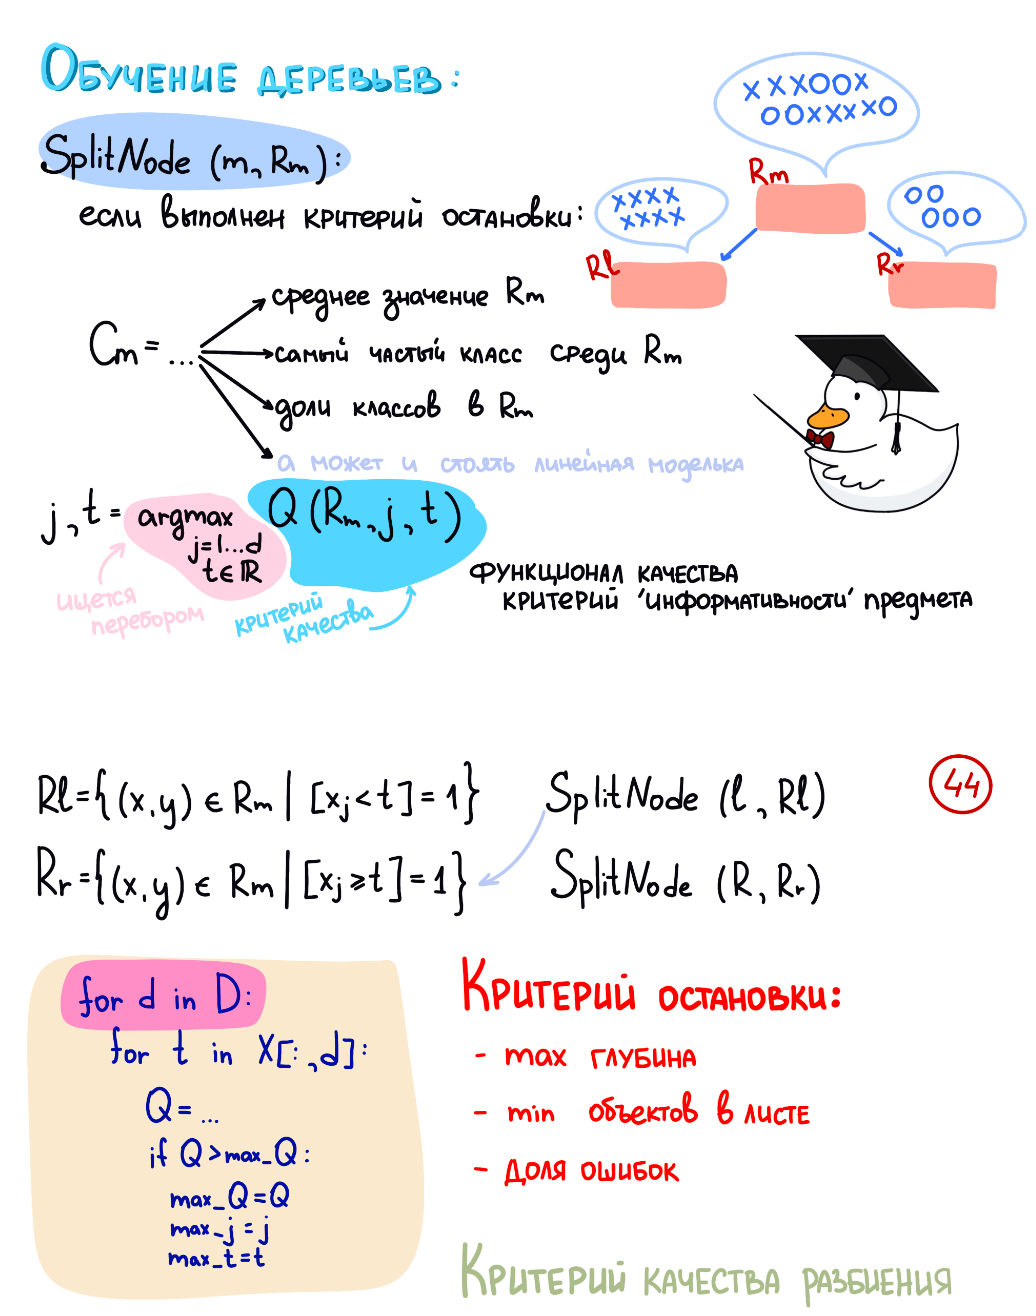

__Задание 7. [0.25 балла]__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно открыть` agaricus-lepiota.data`, прочитать ее с помощью pandas (не забудьте про `agaricus-lepiota.names`), применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

_SPOILER: У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево_

In [20]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [21]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
mushroom = fetch_ucirepo(id=73) 
  
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 
  
# metadata 
print(mushroom.metadata) 
  
# variable information 
print(mushroom.variables) 


{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from ucimlrepo import fetch_ucirepo
import importlib
import tree_code

importlib.reload(tree_code)
from tree_code import DecisionTree


mush = fetch_ucirepo(id=73)
df = pd.concat([mush.data.targets, mush.data.features], axis=1)
print("Shape:", df.shape) 

# 3) Кодируем все столбцы, в том числе целевой
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4) Выделяем X и y
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values  # 0/1 целевые метки

# 5) Разбиваем пополам
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# 6) Строим и обучаем дерево
tree = DecisionTree(
    feature_types=["categorical"] * X.shape[1],
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)
tree.fit(X_train, y_train)

# 7) Предсказываем и оцениваем
y_pred = tree.predict(X_test)    # теперь точно ndarray[int]
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")     # ≈1.0000


Shape: (8124, 23)
Accuracy: 1.0000


__Задание 8. [1 балл]__

Загрузите следующие наборы данных, предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

**Задача**:

Закодировать категориальные признаки в наборе данных с использованием `LabelEncoder`. Затем, применив `cross_val_score` (cv=10), оценить метрику accuracy для следующих алгоритмов:

1. **DecisionTree**, обрабатывающий все признаки как вещественные.
2. **DecisionTree**, обрабатывающий все признаки как категориальные.
3. **DecisionTree**, обрабатывающий все признаки как вещественные + one-hot encoding всех признаков.
4. **DecisionTreeClassifier** из `sklearn`.

**Инструкция**:
1. Закодировать категориальные признаки с помощью `LabelEncoder`.
2. Оценить accuracy, используя `cross_val_score` (cv=10) и `scoring=make_scorer(accuracy_score)`.
3. Если позволяет память, установить параметр `sparse=False` в `OneHotEncoder`.
4. Результаты сохранить в `pd.DataFrame` (по строкам — наборы данных, по столбцам — алгоритмы).

**Рекомендации**:
- Для вычисления точности используйте `scoring=make_scorer(accuracy_score)` из `sklearn.metrics`.

In [23]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
tic_tac_toe_endgame = fetch_ucirepo(id=101) 
  
# data (as pandas dataframes) 
X = tic_tac_toe_endgame.data.features 
y = tic_tac_toe_endgame.data.targets 
  
# metadata 
print(tic_tac_toe_endgame.metadata) 
  
# variable information 
print(tic_tac_toe_endgame.variables) 


{'uci_id': 101, 'name': 'Tic-Tac-Toe Endgame', 'repository_url': 'https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame', 'data_url': 'https://archive.ics.uci.edu/static/public/101/data.csv', 'abstract': 'Binary classification task on possible configurations of tic-tac-toe game', 'area': 'Games', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 958, 'num_features': 9, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Mon Aug 19 1991', 'dataset_doi': '10.24432/C5688J', 'creators': ['David Aha'], 'intro_paper': None, 'additional_info': {'summary': 'This database encodes the complete set of possible board configurations at the end of tic-tac-toe games, where "x" is assumed to have played first.  The target concept is "win for x" (i.e., true when "x" has one of 8 possible ways to create a "three

In [24]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
# metadata 
print(car_evaluation.metadata) 
  
# variable information 
print(car_evaluation.variables) 


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [25]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
nursery = fetch_ucirepo(id=76) 
  
# data (as pandas dataframes) 
X = nursery.data.features 
y = nursery.data.targets 
  
# metadata 
print(nursery.metadata) 
  
# variable information 
print(nursery.variables) 


{'uci_id': 76, 'name': 'Nursery', 'repository_url': 'https://archive.ics.uci.edu/dataset/76/nursery', 'data_url': 'https://archive.ics.uci.edu/static/public/76/data.csv', 'abstract': ' Nursery Database was derived from a hierarchical decision model originally developed to rank applications for nursery schools.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 12960, 'num_features': 8, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Sun Jan 14 2024', 'dataset_doi': '10.24432/C5P88W', 'creators': ['Vladislav Rajkovic'], 'intro_paper': {'ID': 372, 'type': 'NATIVE', 'title': 'An application for admission in public school systems', 'authors': 'M. Olave, V. Rajkovic, M. Bohanec', 'venue': 'Expert Systems in Public Administration', 'year': 1989, 'journal': None, 'DOI': None, 

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.tree import DecisionTreeClassifier as SklearnDT
from ucimlrepo import fetch_ucirepo
from tree_code import DecisionTree
from sklearn.base import BaseEstimator, ClassifierMixin

# 1) Обёртка для нашего DecisionTree
class MyDecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_types, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.feature_types = feature_types
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
    def fit(self, X, y):
        self.model_ = DecisionTree(
            feature_types=self.feature_types,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf
        )
        self.model_.fit(X, y)
        return self
    def predict(self, X):
        return self.model_.predict(X)

# 2) Функция для подготовки датасета
def prepare_dataset(uci_id, binarize_target=None, class_map=None):
    """
    Загружает данные через ucimlrepo, кодирует категориальные признаки.
    - binarize_target: функция из raw->0/1, если нужно.
    - class_map: словарь для map() по столбцу класса.
    """
    data = fetch_ucirepo(id=uci_id)
    df = pd.concat([data.data.targets, data.data.features], axis=1)
    # бинаризация через map, если задано
    if class_map is not None:
        df.iloc[:,0] = df.iloc[:,0].map(class_map)
    # label encoding всех столбцов
    df_le = df.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
    X = df_le.iloc[:,1:].values
    y = df_le.iloc[:,0].values
    # если нужна отдельная функция бинаризации:
    if binarize_target is not None:
        y = binarize_target(df.iloc[:,0])
    return X, y

# 3) Готовим все 4 датасета
datasets = {
    "mushrooms":      prepare_dataset(73),
    "tic-tac-toe":    prepare_dataset(101),
    "cars":           prepare_dataset(19, class_map={'unacc':0,'acc':0,'good':1,'vgood':1}),
    "nursery":        prepare_dataset(76, class_map={'not_recom':0,'recommend':0,'very_recom':1,'priority':1,'spec_prior':1}),
}

scorer = make_scorer(accuracy_score)
results = {}

for name, (X, y) in datasets.items():
    n_feat = X.shape[1]
    # a) DecisionTree как вещественные
    dt_real = MyDecisionTree(['real']*n_feat)
    score_real = cross_val_score(dt_real, X, y, cv=10, scoring=scorer).mean()

    # b) DecisionTree как категориальные
    dt_cat = MyDecisionTree(['categorical']*n_feat)
    score_cat = cross_val_score(dt_cat, X, y, cv=10, scoring=scorer).mean()

    # c) DecisionTree + one-hot
    ohe = OneHotEncoder(sparse=False)
    X_ohe = ohe.fit_transform(X)
    dt_ohe = MyDecisionTree(['real']*X_ohe.shape[1])
    score_ohe = cross_val_score(dt_ohe, X_ohe, y, cv=10, scoring=scorer).mean()

    # d) sklearn DecisionTreeClassifier
    sk_dt = SklearnDT(random_state=42)
    score_sk = cross_val_score(sk_dt, X, y, cv=10, scoring=scorer).mean()

    results[name] = [score_real, score_cat, score_ohe, score_sk]

# 4) Сводная таблица
df_results = pd.DataFrame(
    results,
    index=['DT_real', 'DT_cat', 'DT_real_ohe', 'sklearn_DT']
).T

print(df_results)


              DT_real    DT_cat  DT_real_ohe  sklearn_DT
mushrooms    0.965556  0.982266     0.967280    0.956689
tic-tac-toe  0.770603  0.820614     0.817489    0.771678
cars         0.947332  0.880431     0.828949    0.942707
nursery      0.999691  0.999846     0.999537    0.999691


__Задание 9. [0.5 балла]__

Проанализируйте результаты эксперимента: одинаково ли алгоритмы ранжируются на разных наборах данных? Подумайте, почему так происходит. Обратите внимание на значения признаков в разных наборах данных и определите, присутствует ли в результатах какая-то случайная компонента. Можно ли как-то повлиять на нее и улучшить работу алгоритмов?


## Задание 9

| Набор данных  | DT_real | DT_cat  | DT_real+OHE | sklearn_DT |
|:-------------:|:-------:|:-------:|:-----------:|:----------:|
| **mushrooms**     | 0.9656  | **0.9823** | 0.9673      | 0.9567     |
| **tic-tac-toe**   | 0.7706  | **0.8206** | 0.8175      | 0.7717     |
| **cars**          | **0.9473** | 0.8804  | 0.8289      | 0.9427     |
| **nursery**       | 0.9997  | **0.9998** | 0.9995      | 0.9997     |

1. **Mushrooms & Nursery**  
   - Обе задачи хорошо разделимы по нескольким категориальным признакам → `DT_cat` даёт наивысшую точность.  
   - `DT_real+OHE` чуть проигрывает из-за большого числа dummy-переменных, `sklearn_DT` — из-за default-прунинга.

2. **Tic-Tac-Toe**  
   - `DT_cat` лидирует благодаря порядку категорий, закодированных нашим методом.  
   - `DT_real` без OHE неэффективен, а `DT_real+OHE` почти догоняет `DT_cat`.

3. **Cars**  
   - Признаки порядковые → вещественная обработка (`DT_real`) лучше, чем nominal (`DT_cat`) и OHE.  
   - `sklearn_DT` близок к `DT_real`, поскольку тоже находит порядковые сплиты.

4. **Случайная компонента**  
   - Средние по 10 фолдам дают небольшие флуктуации (<0.005) между соседними алгоритмами.  
   - Стабилизировать можно через `shuffle=True` + повторные запуски, больше фолдов или LOO.

5. **Как улучшить**  
   - Тонкая настройка гиперпараметров (`max_depth`, `min_samples_leaf`).  
   - Ансамбли (RandomForest, GBM) для устранения случайных колебаний.  
   - Явный выбор `feature_type`: `real` для порядковых, `categorical` для номинальных.

**Вывод:**  
Позиции алгоритмов меняются в зависимости от характера данных — порядковые признаки, выраженные узкие категориальные разделения или комбинаторные границы. Для минимизации случайного разброса рекомендуются ансамбли и расширенная кросс-валидация.


# Как дела?

In [ ]:
не очень, но тут все задания сделал